# CPA Attack on masked MAYO - 2 shares

<div class="alert" style="background-color: #f5f0ff; color: #2d1b4e; border: 1px solid #d8c7ff; font-size: 15px;">
<strong>Notebook overview:</strong> This notebook performs a CPA attack on the masked, two-share MAYO implementation. 
The attack targets the <code>P1P1t_times_O</code> function and uses pre-captured masked power traces together with precomputed call indices from <code>01_capture_mayo1_stm32f4.ipynb</code>. Some common helper functions for trace segmentation, leakage modeling, plotting, and result verification are implemented in <code>masked_attack_utils.py</code>.
<br><br>
<font color='#5b2c83'>→ Target:</font> masked MAYO with two shares</br>
<font color='#5b2c83'>→ Target function:</font> <code>P1P1t_times_O</code></br>
<font color='#5b2c83'>→ Input:</font> Raw masked power trace and precomputed peak indices</br>
<font color='#5b2c83'>→ Goal:</font> Recover the oil matrix using share-wise CPA</br>
</div>

In [5]:
from pathlib import Path
import sys
import numpy as np

cwd = Path.cwd()

if cwd.name == "notebooks":
    PROJECT_ROOT = cwd.parent
else:
    PROJECT_ROOT = cwd

DATA_DIR = PROJECT_ROOT / "data"

sys.path.insert(0, str(PROJECT_ROOT))

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML
from masked_attack_utils import check_oil_vector, check_oil_matrix

### Choose data

<div class="alert alert-info" style="background-color: #eaf7fb; color: #1f2933; border-color: #b6e0ef;">
<strong>Select input trace:</strong> Set <code>input_trace</code> to the masked trace that should be analyzed. 
</div>

In [3]:
from data.data import attack_O, attack_P2, attack_P1
masked_raw_trace = np.load(DATA_DIR/"masked_data_raw_trace.npy")

In [3]:
input_trace = masked_raw_trace

### Precalculated segment size pattern from average trace

<div class="alert alert-info" style="background-color: #eaf7fb; color: #1f2933; border-color: #b6e0ef;">
<strong>Peak indices:</strong> The detected peak indices identify the call length for each segment in the captured trace. 
These indices were precomputed in the capture notebook and are used for trace segmentation below.
</div>

In [4]:
peaks = np.load(DATA_DIR/"masked_peaks_2shares.npy")

## Trace Segmentation

In [5]:
from masked_attack_utils import (
    merge_oil_segments_for_share,
    build_segment_records, 
    get_oil_segment_records_for_share
)

## Precalculations

In [6]:
v = 78
o = 8
O = attack_O
limbs = 5

In [7]:
segment_records = build_segment_records(input_trace, peaks)

In [8]:
acc_state0 = np.array(attack_P2, dtype=np.uint64).reshape(v, o, limbs).copy()
acc_state1 = np.zeros((v, o, limbs), dtype=np.uint64)

In [9]:
from masked_attack_utils import (
    get_entries_for_coeff_share,
    get_P1_block
)

## POI inspection

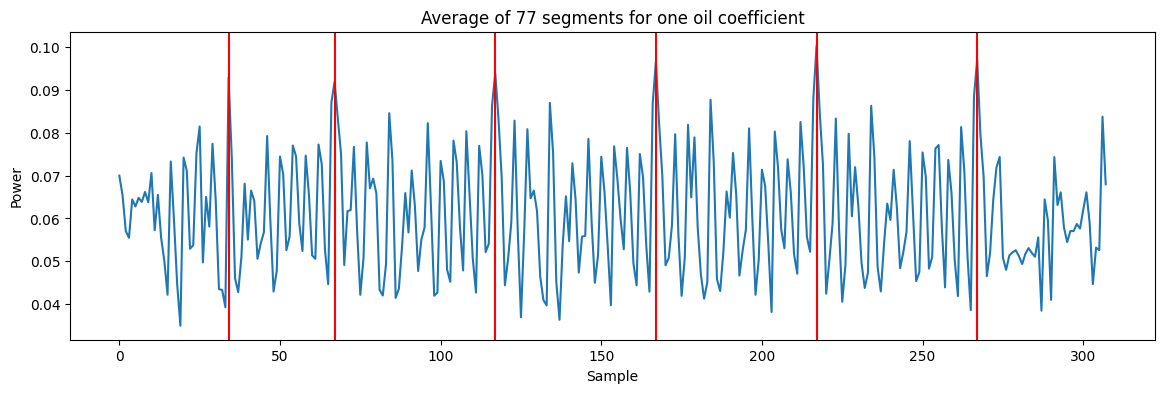

Peaks: [ 67 117 167 217 267]


In [10]:
from scipy.signal import find_peaks
oil_records_for_coeff = get_oil_segment_records_for_share(segment_records, z=0, k=0, share=1, v=78, o=8, n_shares=2)
merged_oil_segments = merge_oil_segments_for_share(oil_records_for_coeff, allowed_lengths=None, target_len=308)
seg = np.mean(np.asarray(merged_oil_segments, dtype=float), axis=0)


peakstest, props = find_peaks(
    seg,
    height=0.09,
    distance=30
)

plt.figure(figsize=(14, 4))
plt.plot(seg)

for p in peakstest:
    plt.axvline(p, color='red')
plt.title("Average of 77 segments for one oil coefficient")
plt.xlabel("Sample")
plt.ylabel("Power")
plt.show()

print("Peaks:", peakstest[1:])

## Correlation Power Analysis

### Leakage Modeling

In [11]:
from masked_attack_utils import (
    hw, 
    mul_table, 
    m_vec_mul_add_model,
    build_hypothesis_hw
)

### Correlation

In [12]:
from masked_attack_utils import (
    normalize_limbs,
    run_cpa,
)

## CPA on one oil coefficient

<div class="alert alert-info" style="background-color: #eaf7fb; color: #1f2933; border-color: #b6e0ef;">
<strong>Single-coefficient CPA:</strong> This section recovers one oil coefficient by attacking each share separately and XORing the recovered share guesses. 
</div>

In [13]:
from masked_attack_utils import (
    plot_abs_share_correlations_n,
    recover_oil_share,
    recover_oil_from_n_shares
)

share guesses: [10, 2]
oil guess: 8
share0 guess: 10
share0 best corr: 0.413986813983501
share1 guess: 2
share1 best corr: 0.3272205797426627


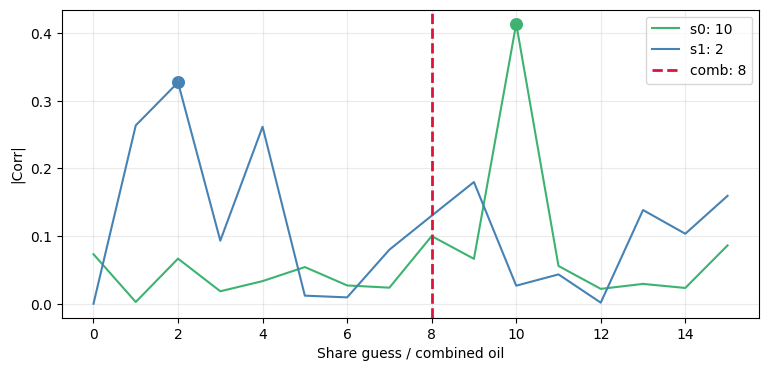

In [14]:
v = 78
o = 8
limbs = 5

acc_state0 = np.array(attack_P2, dtype=np.uint64).reshape(v, o, limbs).copy()
acc_state1 = np.zeros_like(acc_state0)
acc_states2 = [acc_state0, acc_state1]

poi_list2 = [67, 117, 167, 217, 267]
poi_lists2 = [poi_list2, poi_list2]


guess_oil, guesses, corrs, debug = recover_oil_from_n_shares(
    segment_records=segment_records,
    acc_states=acc_states2,
    attack_P1=attack_P1,
    v=v,
    o=o,
    limbs=limbs,
    z=0,
    k=0,
    poi_lists=poi_lists2,
    target_len=308,
    n_shares=2,
    allowed_lengths=None,
)

print("share guesses:", guesses)
print("oil guess:", guess_oil)

for s, corr in enumerate(corrs):
    print(f"share{s} guess:", guesses[s])
    print(f"share{s} best corr:", np.max(np.abs(corr)))

plot_abs_share_correlations_n(
    corrs=corrs,
    guesses=guesses,
)

## CPA on one oil vector

<div class="alert alert-info" style="background-color: #eaf7fb; color: #1f2933; border-color: #b6e0ef;">
<strong>Oil-vector recovery:</strong> This section recovers one full oil-column vector. 
The attack follows the same row-by-row procedure as the unmasked attack, but applies it separately to each share. 
The recovered share vectors are then combined with XOR to obtain the final oil vector. 
The parameters <code>ambiguity_margin</code> and <code>lookahead_top_k</code> control when lookahead is used to resolve uncertain guesses.
</div>

<div class="alert alert-info" style="background-color: #eaf7fb; color: #1f2933; border-color: #b6e0ef;">
<strong>Result verification:</strong> The recovered vector or matrix is compared against the known reference oil matrix. 
A green result indicates a full match, while a red result indicates that at least one coefficient was recovered incorrectly.
</div>

In [15]:
from masked_attack_utils import update_acc_for_coeff

In [16]:
def recover_oil_vector_share(
    column,
    share,
    segment_records,
    acc_state_share,
    attack_P1,
    v,
    o,
    limbs,
    poi_list,
    num_rows=None,
    ambiguity_margin=0.2,
    lookahead_top_k=2,
    target_len=308,
    n_shares=3,
    allowed_lengths=None,
    zero_first_row_rule=True,
    zero_corr_threshold=0.1,
    zero_rule_shares=None,
):
    if num_rows is None:
        num_rows = v

    if zero_rule_shares is None:
        zero_rule_shares = list(range(1, n_shares))

    recovered_vector = []
    margins = []
    debug_rows = []

    def analyze_row(acc_state_local, row_idx):
        guess, corr, poi_lists_out, power, hyp, debug = recover_oil_share(
            segment_records=segment_records,
            acc_state_share=acc_state_local,
            attack_P1=attack_P1,
            v=v,
            o=o,
            limbs=limbs,
            z=row_idx,
            k=column,
            share=share,
            poi_list=poi_list,
            target_len=target_len,
            n_shares=n_shares,
            allowed_lengths=allowed_lengths,
        )

        abs_corr = np.abs(corr)
        guess = int(guess)
        winner_corr = corr[guess]

        masked = np.array(abs_corr, copy=True)
        masked[guess] = -np.inf

        next_best_guess = int(np.argmax(masked))
        next_best_corr = corr[next_best_guess]
        margin = abs_corr[guess] - abs_corr[next_best_guess]

        return {
            "guess": guess,
            "corr": corr,
            "winner_corr": winner_corr,
            "next_best_guess": next_best_guess,
            "next_best_corr": next_best_corr,
            "margin": margin,
            "debug": debug,
            "poi_lists": poi_lists_out,
            "power": power,
            "hyp": hyp,
        }

    for row in range(num_rows):
        analysis = analyze_row(acc_state_share, row)

        local_best = analysis["guess"]
        corr = analysis["corr"]
        local_winner_corr = analysis["winner_corr"]
        local_next_best_guess = analysis["next_best_guess"]
        local_next_best_corr = analysis["next_best_corr"]
        local_margin = analysis["margin"]

        final_guess = local_best
        final_margin = local_margin

        used_lookahead = False
        used_zero_rule = False
        lookahead_details = None

        max_abs_corr = float(np.max(np.abs(corr)))

        if (
            zero_first_row_rule
            and row == 0
            and share in zero_rule_shares
            and max_abs_corr < zero_corr_threshold
        ):
            final_guess = 0
            final_margin = local_margin
            used_zero_rule = True

        if (
            not used_zero_rule
            and row + 1 < num_rows
            and local_margin < ambiguity_margin
        ):
            used_lookahead = True

            abs_corr = np.abs(corr)
            top_candidates = np.argsort(abs_corr)[-lookahead_top_k:][::-1]

            best_candidate = None
            best_total_score = -np.inf
            best_info = None
            candidate_infos = []

            for cand in top_candidates:
                cand = int(cand)

                current_abs = np.abs(corr)
                current_corr = corr[cand]

                masked = np.array(current_abs, copy=True)
                masked[cand] = -np.inf

                current_next_best_guess = int(np.argmax(masked))
                current_next_best_corr = corr[current_next_best_guess]
                current_margin = (
                    current_abs[cand]
                    - current_abs[current_next_best_guess]
                )

                candidate_acc_state = update_acc_for_coeff(
                    acc_state=acc_state_share.copy(),
                    guessed_coeff=cand,
                    attack_P1=attack_P1,
                    v=v,
                    limbs=limbs,
                    z=row,
                    k0=column,
                )

                next_analysis = analyze_row(candidate_acc_state, row + 1)

                next_guess = next_analysis["guess"]
                next_winner_corr = next_analysis["winner_corr"]
                next_margin = next_analysis["margin"]

                total_score = (
                    np.abs(current_corr)
                    + current_margin
                    + np.abs(next_winner_corr)
                    + next_margin
                )

                info = {
                    "candidate": cand,
                    "current_corr": current_corr,
                    "current_margin": current_margin,
                    "next_guess": next_guess,
                    "next_winner_corr": next_winner_corr,
                    "next_margin": next_margin,
                    "total_score": total_score,
                }

                candidate_infos.append(info)

                if total_score > best_total_score:
                    best_total_score = total_score
                    best_candidate = cand
                    best_info = info

            final_guess = int(best_candidate)

            abs_corr = np.abs(corr)
            masked = np.array(abs_corr, copy=True)
            masked[final_guess] = -np.inf

            final_next_best_guess = int(np.argmax(masked))
            final_margin = abs_corr[final_guess] - abs_corr[final_next_best_guess]

            lookahead_details = {
                "candidates": candidate_infos,
                "chosen": best_info,
            }

        recovered_vector.append(final_guess)
        margins.append(final_margin)

        decision = (
            "ZERO_RULE"
            if used_zero_rule
            else ("LOOKAHEAD" if used_lookahead else "DIRECT")
        )

        print(
            f"share={share}, row={row:2d}, "
            f"local_best={local_best}, final_guess={final_guess}, "
            f"local_corr={local_winner_corr:.6f}, "
            f"max_abs_corr={max_abs_corr:.6f}, "
            f"next_best_guess={local_next_best_guess}, "
            f"next_best_corr={local_next_best_corr:.6f}, "
            f"local_margin={local_margin:.6f}, "
            f"{decision}"
        )

        if used_lookahead and lookahead_details is not None:
            print("    lookahead candidates:")
            for info in lookahead_details["candidates"]:
                print(
                    f"      cand={info['candidate']}, "
                    f"curr_corr={info['current_corr']:.6f}, "
                    f"curr_margin={info['current_margin']:.6f}, "
                    f"next_guess={info['next_guess']}, "
                    f"next_winner_corr={info['next_winner_corr']:.6f}, "
                    f"next_margin={info['next_margin']:.6f}, "
                    f"total_score={info['total_score']:.6f}"
                )

            chosen = lookahead_details["chosen"]
            print(
                f"    chosen_by_lookahead: cand={chosen['candidate']}, "
                f"next_guess={chosen['next_guess']}, "
                f"total_score={chosen['total_score']:.6f}"
            )

        if used_zero_rule:
            print(
                f"    zero_rule: row=0, share={share}, "
                f"max_abs_corr={max_abs_corr:.6f} < {zero_corr_threshold}, "
                f"forcing final_guess=0"
            )

        acc_state_share = update_acc_for_coeff(
            acc_state=acc_state_share,
            guessed_coeff=final_guess,
            attack_P1=attack_P1,
            v=v,
            limbs=limbs,
            z=row,
            k0=column,
        )

        debug_rows.append({
            "share": share,
            "row": row,
            "local_best": local_best,
            "final_guess": final_guess,
            "local_margin": local_margin,
            "final_margin": final_margin,
            "used_lookahead": used_lookahead,
            "used_zero_rule": used_zero_rule,
            "max_abs_corr": max_abs_corr,
            "zero_corr_threshold": zero_corr_threshold,
            "lookahead_details": lookahead_details,
            "analysis": analysis,
        })

    print(f"share={share} mean margin:", np.mean(margins))
    print(f"share={share} min margin :", np.min(margins))
    print(f"share={share} max margin :", np.max(margins))
    print(
        f"acc_state_share[{share}][0,0]:",
        [hex(int(x)) for x in acc_state_share[0, 0]],
    )

    return recovered_vector, acc_state_share, debug_rows

In [17]:
def recover_oil_vector_n_shares(
    column,
    segment_records,
    acc_list,
    attack_P1,
    v,
    o,
    limbs,
    poi_lists,
    n_shares,
    num_rows=None,
    ambiguity_margin=0.2,
    lookahead_top_k=2,
    target_len=308,
    allowed_lengths=None,
    zero_first_row_rule=True,
    zero_corr_threshold=0.12,
    zero_rule_shares=None,
):
    if num_rows is None:
        num_rows = v

    if len(acc_list) != n_shares:
        raise ValueError(f"acc_list must contain {n_shares} states")

    if len(poi_lists) != n_shares:
        raise ValueError(f"poi_lists must contain {n_shares} POI lists")

    if zero_rule_shares is None:
        zero_rule_shares = list(range(1, n_shares))

    share_vectors = []
    acc_states_after = []
    debug_by_share = []

    for share in range(n_shares):
        share_vec, acc_after, debug_rows = recover_oil_vector_share(
            column=column,
            share=share,
            segment_records=segment_records,
            acc_state_share=acc_list[share].copy(),
            attack_P1=attack_P1,
            v=v,
            o=o,
            limbs=limbs,
            poi_list=poi_lists[share],
            num_rows=num_rows,
            ambiguity_margin=ambiguity_margin,
            lookahead_top_k=lookahead_top_k,
            target_len=target_len,
            n_shares=n_shares,
            allowed_lengths=allowed_lengths,
            zero_first_row_rule=zero_first_row_rule,
            zero_corr_threshold=zero_corr_threshold,
            zero_rule_shares=zero_rule_shares,
        )

        share_vectors.append(share_vec)
        acc_states_after.append(acc_after)
        debug_by_share.append(debug_rows)

    oil_vector = []

    for row in range(num_rows):
        x = 0
        for share in range(n_shares):
            x ^= int(share_vectors[share][row])
        oil_vector.append(x)

    return oil_vector, share_vectors, acc_states_after, debug_by_share

In [ ]:
acc_state0 = np.array(attack_P2, dtype=np.uint64).reshape(v, o, limbs).copy()
acc_state1 = np.zeros((v, o, limbs), dtype=np.uint64)
column = 0

acc_list = [
    acc_state0.copy(),
    acc_state1.copy(),
]

poi_list0=[67, 117, 167, 217, 267]
poi_list1=[67, 117, 167, 217, 267]
poi_list2 = [poi_list0, poi_list1]

oil_vector, share_vectors, acc_states_after, debug_by_share = (
    recover_oil_vector_n_shares(
        column=column,
        segment_records=segment_records,
        acc_list=acc_list,
        attack_P1=attack_P1,
        v=v,
        o=o,
        limbs=limbs,
        poi_lists=poi_lists2,
        n_shares=2,
        ambiguity_margin=0.25,
        lookahead_top_k=3,
        target_len=308,
        allowed_lengths=None,
    )
)

In [19]:
check_oil_vector(oil_vector, attack_O, column, o=o)

Recovered oil vector:
[ 8  5  0  5  0  8 15  8 12  3  7 14  0  7  9 12 13 10 14  4  5  9 11  8
 14  7  1 14  2 11 14  7  8  0  0  1 10  2  3  3 11 13  2  2 14  1 15  8
  2  0  8 15  6 11 10  2  2  1 15  0  7  6  9 10  9  6  9  2  8 13  1  0
  6  7 14  1  8 13]
True oil vector:
[ 8  5  0  5  0  8 15  8 12  3  7 14  0  7  9 12 13 10 14  4  5  9 11  8
 14  7  1 14  2 11 14  7  8  0  0  1 10  2  3  3 11 13  2  2 14  1 15  8
  2  0  8 15  6 11 10  2  2  1 15  0  7  6  9 10  9  6  9  2  8 13  1  0
  6  7 14  1  8 13]


## CPA on full oil matrix

<div class="alert alert-info" style="background-color: #eaf7fb; color: #1f2933; border-color: #b6e0ef;">
<strong>Full matrix recovery:</strong> The full oil matrix is recovered column by column. 
Each coefficient is recovered by combining the two independently attacked shares.
</div>

In [20]:
def recover_oil_matrix_n_shares(
    segment_records,
    acc_list_init,
    attack_P1,
    v,
    o,
    limbs,
    poi_lists,
    n_shares,
    num_rows=None,
    ambiguity_margin=0.2,
    lookahead_top_k=2,
    target_len=308,
    allowed_lengths=None,
    zero_first_row_rule=True,
    zero_corr_threshold=0.12,
    zero_rule_shares=None,
):
    if num_rows is None:
        num_rows = v

    if zero_rule_shares is None:
        zero_rule_shares = list(range(1, n_shares))

    acc_list = [
        np.array(acc_list_init[s], copy=True)
        for s in range(n_shares)
    ]

    recovered_O_matrix = np.zeros((num_rows, o), dtype=np.int64)

    recovered_share_matrices = [
        np.zeros((num_rows, o), dtype=np.int64)
        for _ in range(n_shares)
    ]

    debug_by_column = []

    for column in range(o):
        print(f"\n===== Recovering column {column} =====")

        (
            oil_vector,
            share_vectors,
            acc_states_after,
            debug_by_share,
        ) = recover_oil_vector_n_shares(
            column=column,
            segment_records=segment_records,
            acc_list=acc_list,
            attack_P1=attack_P1,
            v=v,
            o=o,
            limbs=limbs,
            poi_lists=poi_lists,
            n_shares=n_shares,
            num_rows=num_rows,
            ambiguity_margin=ambiguity_margin,
            lookahead_top_k=lookahead_top_k,
            target_len=target_len,
            allowed_lengths=allowed_lengths,
            zero_first_row_rule=zero_first_row_rule,
            zero_corr_threshold=zero_corr_threshold,
            zero_rule_shares=zero_rule_shares,
        )

        recovered_O_matrix[:, column] = np.asarray(oil_vector, dtype=np.int64)

        for share in range(n_shares):
            recovered_share_matrices[share][:, column] = np.asarray(
                share_vectors[share],
                dtype=np.int64,
            )

        acc_list = [
            np.array(acc_states_after[s], copy=True)
            for s in range(n_shares)
        ]

        debug_by_column.append({
            "column": column,
            "oil_vector": oil_vector,
            "share_vectors": share_vectors,
            "debug_by_share": debug_by_share,
        })

    return (
        recovered_O_matrix,
        recovered_share_matrices,
        acc_list,
        debug_by_column,
    )

In [ ]:
poi_list2 = [67, 117, 167, 217, 267]

recovered_O_matrix, recovered_share_matrices, acc_list_after, debug_by_column = recover_oil_matrix_n_shares(
    segment_records=segment_records,
    acc_list_init=[
        acc_state0.copy(),
        acc_state1.copy(),
    ],
    attack_P1=attack_P1,
    v=v,
    o=o,
    limbs=limbs,
    poi_lists=poi_lists2,
    n_shares=2,
    ambiguity_margin=0.25,
    lookahead_top_k=3,
    target_len=308,
    allowed_lengths=None,
)

In [22]:
check_oil_matrix(recovered_O_matrix, attack_O, v, o)